## Bayesian Causal Forest for HTE
**Model**: BCF for log-rate outcomes (normal on log-rate): model baseline log-rate μ(X) and treatment effect surface τ(X) with treatment A and include PS p(X) (or logit PS) as a covariate to correct for targeted selection.

To model BART with a count outcome treat as a GLM with the additional terms of a log offset and overdispersion term from the Negative Binomial.
$$Y_i \sim \text{NegativeBinomial}(\mu = \lambda_i, \alpha)$$
$$\log(\lambda_i) = \log(\text{offset}_i) + \mu(x_i, \hat{p}) + \tau(x_i) \cdot T_i$$
where $\alpha$ is the overdispersion term and *offset* is the follow-time per patient
- $\mu(x_i, \pi_i)$ = the **prognostic function** — captures baseline outcome risk, regardless of treatment. $\pi_i$ are the propensity score estimates.
- $\tau(x_i)$ = the **treatment effect function** — captures how the treatment effect varies with covariates (this is CATE)
- $A \in {0,1}$ is the treatment indicator

In [1]:
import os
import sys
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from scipy.stats import norm, t
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
rng = np.random.default_rng(123)

output_folder = "ISYE6420/Project/"

## Data Loading and Preparation

In [2]:
# Import configurations
dx_name = "asthma"
version = "v7_040226"

cohort = pd.read_csv(f"ISYE6420\\Project\\asthma_weighted_cohort.csv")
print(len(cohort))

65417


In [3]:
y = cohort["outcome"].values
treatment = cohort["exposure"].values
follow_up_time = cohort["follow_up_time"].values
y_data = y.copy()

### 1. Prognostic Model $\mu(X, \hat{p})$

In [4]:
X = cohort.drop(columns=["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"])
# convert True False columns to int
X = X.astype(int)
# Logit transform the propensity scores for better modeling
propensity_score = cohort["ps_score"]
eps = 1e-6
ps_values = np.clip(propensity_score, eps, 1 - eps)
logit_ps = np.log(ps_values / (1 - ps_values))
X['logit_ps'] = logit_ps
X_mu = X.values

prognostic_model_config = {
    "n_trees": 200,
    "beta_prior": 2,
    "alpha_prior": 0.95,
}

In [5]:
num_exac_pats = cohort[cohort['outcome'] > 0]['patid'].nunique()/ cohort['patid'].nunique()
print(f"Proportion of patients with at least one event: {num_exac_pats:.2%}")

Proportion of patients with at least one event: 5.51%


### 2. $\tau$(X) Treatment Effect Model

The treatment BART is fitted on the **residual** after subtracting the posterior mean of μ.
Only **treated** patients contribute signal to τ — we restrict to T=1 for the fit,
then predict τ for everyone to compute CATTs.

Key differences from the prognostic model:
- Outcome is the residual `r = y - mu_hat`, not the raw log-rate
- Fewer trees (`m=50`) to regularise τ toward zero — avoids overfitting the treatment surface
- `logit_ps` is included in `X_tau` to keep confounding correction active

In [6]:
# Treatment indicator as int
T = treatment.astype(int)

# Feature matrix for tau: same covariates as mu, but add treatment indicator instead of propensity score
X["T"] = T
X_tau = X.values.astype(float)

tau_model_config = {
    "n_trees": 50,       # stronger regularisation toward zero for treatment effects
    "beta_prior": 2,
    "alpha_prior": 0.5,
}


## Full Joint BCF Model

New model specification with intercept:
$$log(Y_i) = \mu(x_i, \pi_i) + \tau(x_i) \cdot T_i + log(\text{offset}) + I+\epsilon_i$$
where the intercept, $I \sim N(-3, 0.5)$


Implementation in PyMC ($\epsilon$ already present in model)
$$log(Y) = X_{\mu} + X_{\tau} + log(\text{offset}) +I$$

- $X_\mu$ = full covariates + logit_ps
- $X_\tau$ = full covariates + treatment indicator T

In [9]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data,
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data,
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )
    # Add constant intercept
    constant_intercept = norm.ppf(0.055)
    # Log-link with offset
    lambda_ = pm.Deterministic("lambda_", mu + tau * T_shared + np.log(offset) + constant_intercept)
    # Overdispertion term
    kappa = pm.Exponential("kappa", lam=1)
    # Psi term
    #psi = pm.Beta("psi", alpha=1, beta=1)

    # Likelihood as a negative binomial for count data
    y_likelihood = pm.NegativeBinomial("y_likelihood", mu=pm.math.exp(lambda_), alpha=kappa, observed=y_obs)

    trace_bcf = pm.sample(1000, tune=2000, random_seed=rng, chains=4, target_accept=0.95)

ppc = pm.sample_posterior_predictive(trace_bcf, model=bcf_joint)
az.summary(trace_bcf, var_names=["kappa"], round_to=3, hdi_prob=0.95)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>PGBART: [mu]
>>PGBART: [tau]
>NUTS: [kappa]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 15995 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_likelihood]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,0.556,0.037,0.486,0.629,0.001,0.001,1147.239,1290.413,1.003


In [10]:
# Extract CATTs from joint model
mu_joint  = trace_bcf.posterior["mu"].mean(dim=["chain", "draw"]).values
tau_joint = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
tau_joint_sd = trace_bcf.posterior["tau"].std(dim=["chain", "draw"]).values

print(f"Joint CATT summary — mean: {tau_joint.mean():.4f}, sd: {tau_joint.std():.4f}")
print(f"ATT (treated only): {tau_joint[T == 1].mean():.4f}")

Joint CATT summary — mean: -0.0272, sd: 0.1500
ATT (treated only): -0.0458


array([[<Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa'}>]], dtype=object)

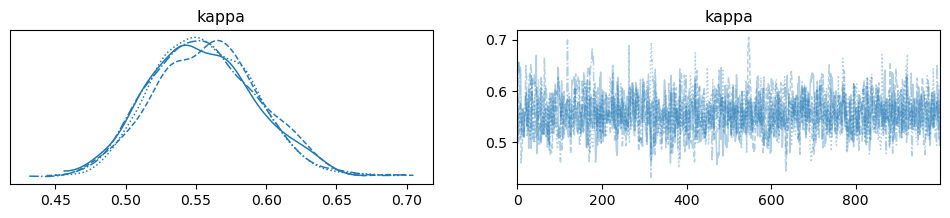

In [11]:
az.plot_trace(trace_bcf, var_names=["kappa"])

In [12]:
az.to_netcdf(trace_bcf, f"{output_folder}bcf_original_priors.nc")

'ISYE6420/Project/bcf_original_priors.nc'

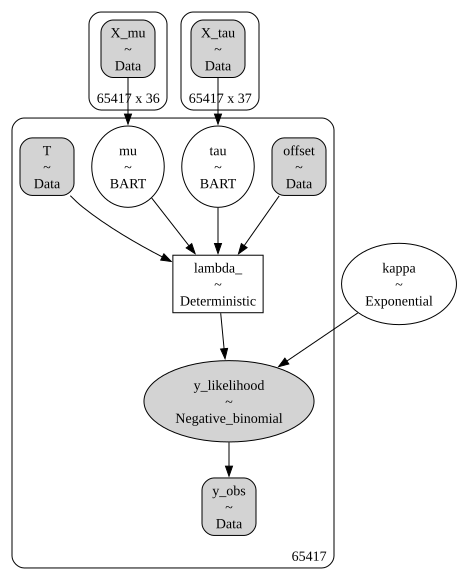

In [13]:
# create DAG
pm.model_to_graphviz(bcf_joint)

## Outcome Analysis

In [8]:
# Load trace from nc file
trace_bcf = az.from_netcdf(f"{output_folder}bcf_joint_trace_neg_bin.nc")
az.summary(trace_bcf, var_names=["kappa"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,0.557,0.037,0.486,0.625,0.001,0.001,2776.0,2537.0,1.0


In [9]:
with pm.Model() as bcf_joint:
    # Re-declare data containers
    X_mu_shared = pm.Data("X_mu", X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Re-declare the BART and parameters
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data,
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data,
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )
    constant_intercept = norm.ppf(0.055) 
    lambda_ = pm.Deterministic("lambda_", mu + tau * T_shared + np.log(offset) + constant_intercept)
    kappa = pm.Exponential("kappa", lam=1)
    
    y_likelihood = pm.NegativeBinomial(
        "y_likelihood", 
        mu=pm.math.exp(lambda_), 
        alpha=kappa, 
        observed=y_obs
    )

# Now you can run PPC using the trace loaded from the .nc file
with bcf_joint:
    ppc = pm.sample_posterior_predictive(trace_bcf)

Sampling: [y_likelihood]


Output()

## Diagnostic Workflow

In [10]:
zero_ppc = (ppc.posterior_predictive["y_likelihood"] == 0).mean(dim=["chain", "draw"])
print(zero_ppc.values.mean())  # compare to actual zero rate

0.9457902876928016


BFMI < 0.3 indicates potential issues with sampler efficiency.


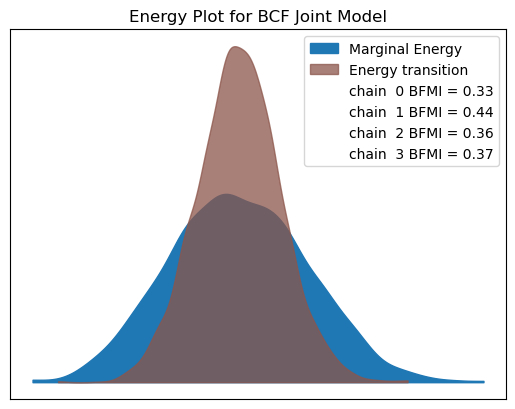

In [11]:
# Check Sampler efficiency through energy plot
print("BFMI < 0.3 indicates potential issues with sampler efficiency.")
energy_ax = az.plot_energy(trace_bcf)
energy_ax.set_title("Energy Plot for BCF Joint Model")
plt.show()

## Goodness of Fit Check

Text(0.5, 1.0, 'Comparison in Log-Space')

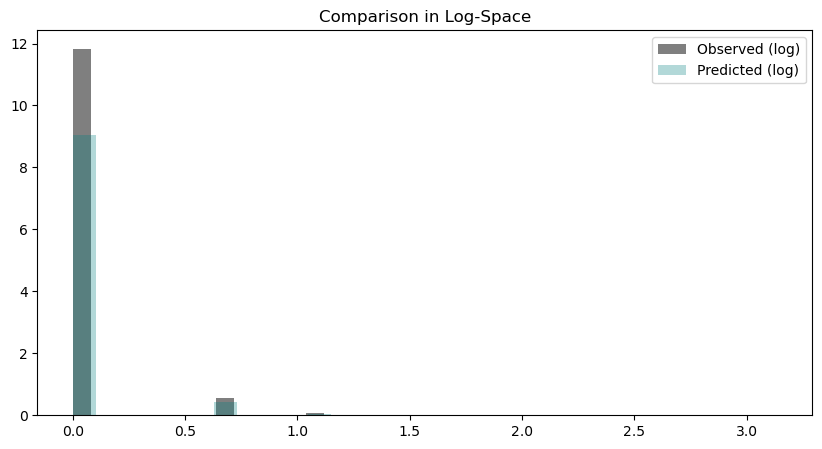

In [12]:
# Manually plot the log of the observed vs predicted
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(y_data), bins=30, density=True, alpha=0.5, label="Observed (log)", color="black")

# Pull a few samples from the posterior predictive
pp_counts = ppc.posterior_predictive["y_likelihood"].values.flatten()
plt.hist(np.log1p(pp_counts), bins=30, density=True, alpha=0.3, label="Predicted (log)", color="teal")

plt.legend()
plt.title("Comparison in Log-Space")

Text(0.5, 1.0, 'Distribution of Log-Likelihood (lambda_)')

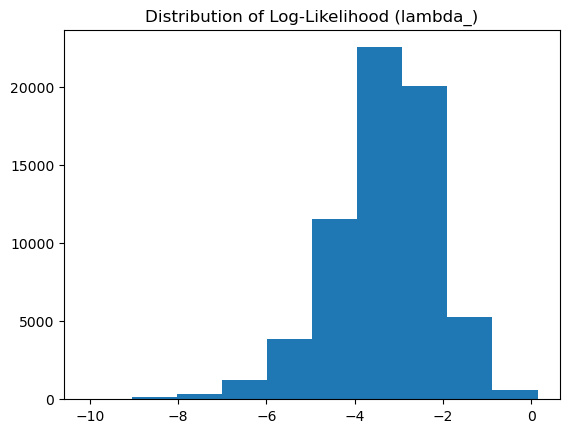

In [13]:
# Check the mean of your predicted lambda before the exponential
plt.hist(trace_bcf.posterior["lambda_"].mean(dim=["chain", "draw"]).values.flatten())
plt.title("Distribution of Log-Likelihood (lambda_)")

## Visualising Treatment Effects

Text(0.5, 1.0, 'Distribution of Individual Treatment Effects')

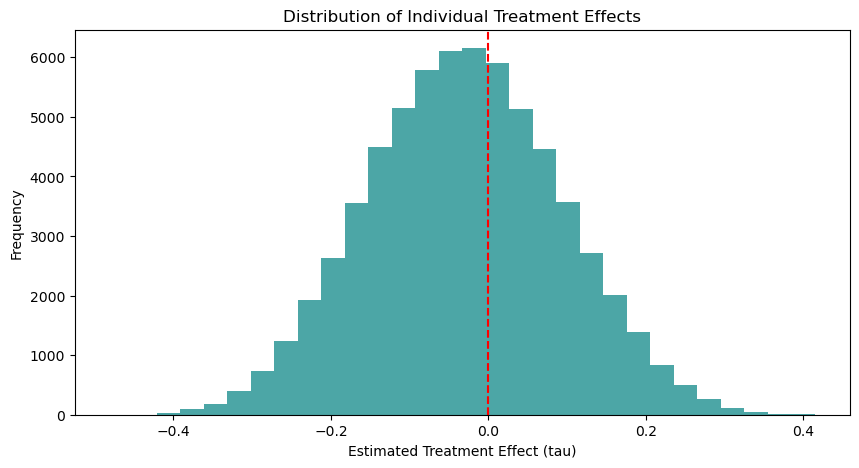

In [14]:
# Visualize the distribution of the Individual Treatment Effects (ITE)
# We take the mean of tau across the posterior samples for each observation
ite_means = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"])

plt.figure(figsize=(10, 5))
plt.hist(ite_means, bins=30, color="teal", alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Estimated Treatment Effect (tau)")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Treatment Effects")

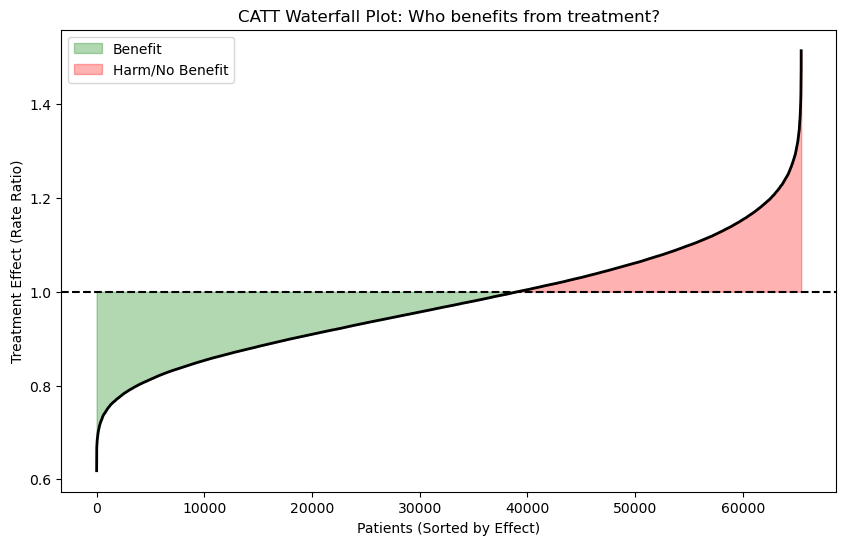

In [15]:
# 1. Get the mean Tau for each of the 20,500 observations
# We convert to Rate Ratio (exp) for the Y-axis
catt_estimates = np.exp(trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values)

# 2. Sort them
sorted_catt = np.sort(catt_estimates)
index = np.arange(len(sorted_catt))

plt.figure(figsize=(10, 6))
plt.fill_between(index, 1, sorted_catt, where=(sorted_catt < 1), color='green', alpha=0.3, label='Benefit')
plt.fill_between(index, 1, sorted_catt, where=(sorted_catt > 1), color='red', alpha=0.3, label='Harm/No Benefit')
plt.plot(index, sorted_catt, color='black', linewidth=2)
plt.axhline(1, color='black', linestyle='--')
plt.ylabel("Treatment Effect (Rate Ratio)")
plt.xlabel("Patients (Sorted by Effect)")
plt.title("CATT Waterfall Plot: Who benefits from treatment?")
plt.legend()
plt.show()

C:\Users\nedee\AppData\Local\Temp\ipykernel_27380\259882038.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_stats.index, y=summary_stats.values, palette="mako")


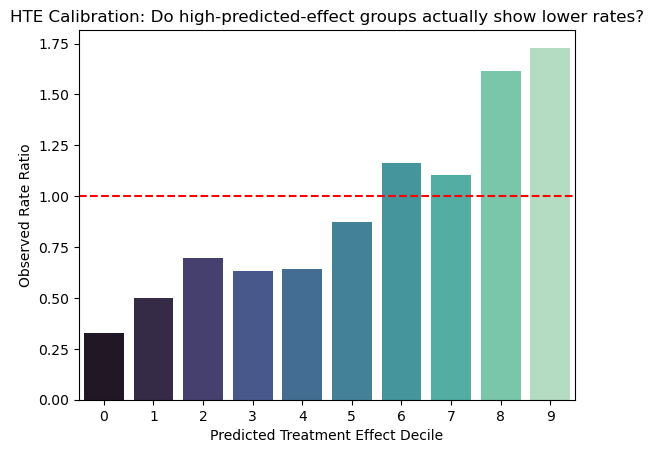

In [16]:
# Create a DataFrame with predicted tau and actual outcomes
df_eval = pd.DataFrame({
    'pred_tau': catt_estimates,
    'observed_y': y_data,
    'T': T
})

# Bin by predicted effect deciles
df_eval['decile'] = pd.qcut(df_eval['pred_tau'], 10, labels=False)

# Calculate observed Rate Ratio per decile
# (Rate in Treated / Rate in Control)
summary_stats = df_eval.groupby('decile').apply(
    lambda x: (x[x['T']==1]['observed_y'].mean()) / (x[x['T']==0]['observed_y'].mean())
)

sns.barplot(x=summary_stats.index, y=summary_stats.values, palette="mako")
plt.axhline(1, color='red', linestyle='--')
plt.ylabel("Observed Rate Ratio")
plt.xlabel("Predicted Treatment Effect Decile")
plt.title("HTE Calibration: Do high-predicted-effect groups actually show lower rates?")
plt.show()

## Interpretable Outputs

In [17]:
def get_tau_samples(trace):
    """Flatten posterior tau samples → (total_draws, N)"""
    tau = trace.posterior["tau"].values          # (chains, draws, N)
    return tau.reshape(-1, tau.shape[-1])        # (4000, N)

In [18]:
# 1. Individual Level IRRs
tau_samples = get_tau_samples(trace_bcf) 
irr_samples = np.exp(tau_samples)

# Calculate Posterior Mean and 95% HDI for each patient
irr_mean = irr_samples.mean(axis=(0, 1))
irr_hdi = az.hdi(irr_samples, hdi_prob=0.95)

# 2. Overall CATT (on log-rate scale first, then summarized)
# Filter tau for treated patients only (T=1)
treated_indices = np.where(T == 1)[0]
catt_samples = tau_samples[:, treated_indices].mean(axis=1)  # (total_draws,) — CATT posterior for treated

catt_mean = catt_samples.mean()
catt_hdi = az.hdi(catt_samples, hdi_prob=0.95)

print(f"Overall CATT (log-scale): {catt_mean:.3f} 95% HDI {catt_hdi}")
print(f"Overall CATT (IRR scale): {np.exp(catt_mean):.3f}")

C:\Users\nedee\AppData\Local\Temp\ipykernel_27380\2133956032.py:7: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  irr_hdi = az.hdi(irr_samples, hdi_prob=0.95)


Overall CATT (log-scale): -0.043 95% HDI [-0.11568583  0.03836368]
Overall CATT (IRR scale): 0.957


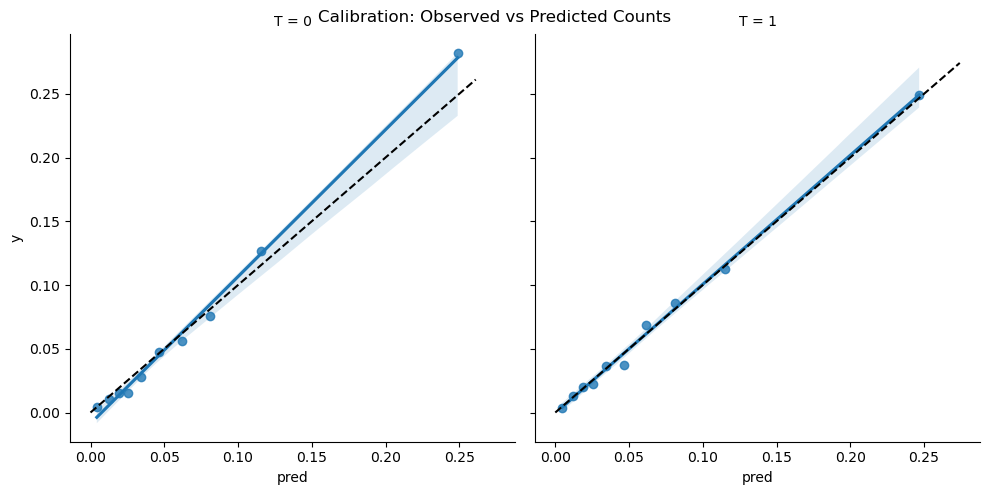

In [19]:
y_pred_mean = ppc.posterior_predictive["y_likelihood"].mean(axis=(0, 1)).values

def plot_calibration(y_true, y_pred, treatment, title):
    df_cal = pd.DataFrame({'y': y_true, 'pred': y_pred, 'T': treatment})
    df_cal['decile'] = pd.qcut(df_cal['pred'], 10, labels=False, duplicates='drop')
    
    cal_data = df_cal.groupby(['T', 'decile']).agg({'y': 'mean', 'pred': 'mean'}).reset_index()
    
    sns.lmplot(data=cal_data, x='pred', y='y', col='T')
    for ax in plt.gcf().axes:
        ax.plot([0, ax.get_xlim()[1]], [0, ax.get_xlim()[1]], 'k--')
    plt.suptitle(title)

plot_calibration(y_data, y_pred_mean, T, "Calibration: Observed vs Predicted Counts")

C:\Users\nedee\AppData\Local\Temp\ipykernel_27380\1857973658.py:2: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  tau_hdi = az.hdi(tau_samples, hdi_prob=0.94)


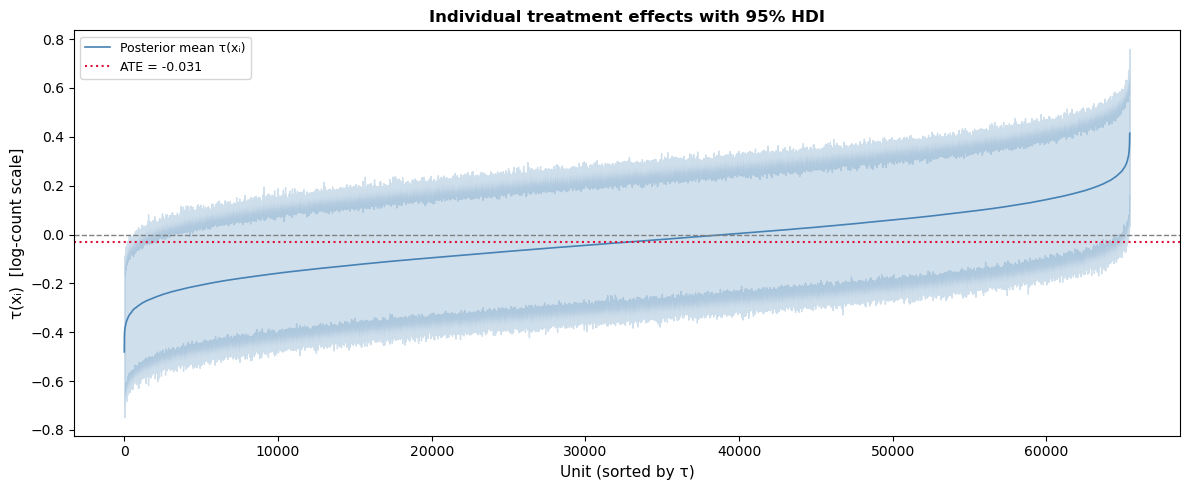

In [20]:
tau_mean = tau_samples.mean(axis=(0))
tau_hdi = az.hdi(tau_samples, hdi_prob=0.94)
sort_idx = np.argsort(tau_mean)
tau_sorted_mean = tau_mean[sort_idx]
tau_sorted_lo   = tau_hdi[sort_idx, 0]
tau_sorted_hi   = tau_hdi[sort_idx, 1]

fig, ax = plt.subplots(figsize=(12, 5))
n = len(tau_sorted_mean)
xs = np.arange(n)

ax.fill_between(xs, tau_sorted_lo, tau_sorted_hi, alpha=0.25, color="steelblue")
ax.plot(xs, tau_sorted_mean, lw=1.2, color="steelblue", label="Posterior mean τ(xᵢ)")
ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.axhline(tau_mean.mean(), color="crimson", lw=1.5, linestyle=":", label=f"ATE = {tau_mean.mean():.3f}")
ax.set_xlabel("Unit (sorted by τ)", fontsize=11)
ax.set_ylabel("τ(xᵢ)  [log-count scale]", fontsize=11)
ax.set_title("Individual treatment effects with 95% HDI", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig("fig2_caterpillar.png", dpi=150, bbox_inches="tight")
plt.show()


## Subgroup CATTs

(<Axes: title={'center': 'CATT by GINA Step'}, xlabel='CATT — posterior mean τ  [log-count scale]'>,
   level      n      mean      lo94      hi94      lo50      hi50    p_pos
 0     0  27186  0.025209 -0.083559  0.149266 -0.017962  0.062372  0.65525
 1     1   5473 -0.021277 -0.119554  0.077840 -0.049879  0.019309  0.34150
 2     2   8454 -0.068341 -0.154588  0.027519 -0.102138 -0.036581  0.08075
 3     3   4727 -0.078569 -0.164948  0.018634 -0.111570 -0.047953  0.05850
 4     4  10469 -0.086813 -0.179645  0.006804 -0.119869 -0.054555  0.04550
 5     5   9108 -0.077604 -0.172821  0.014524 -0.110694 -0.044551  0.06275)

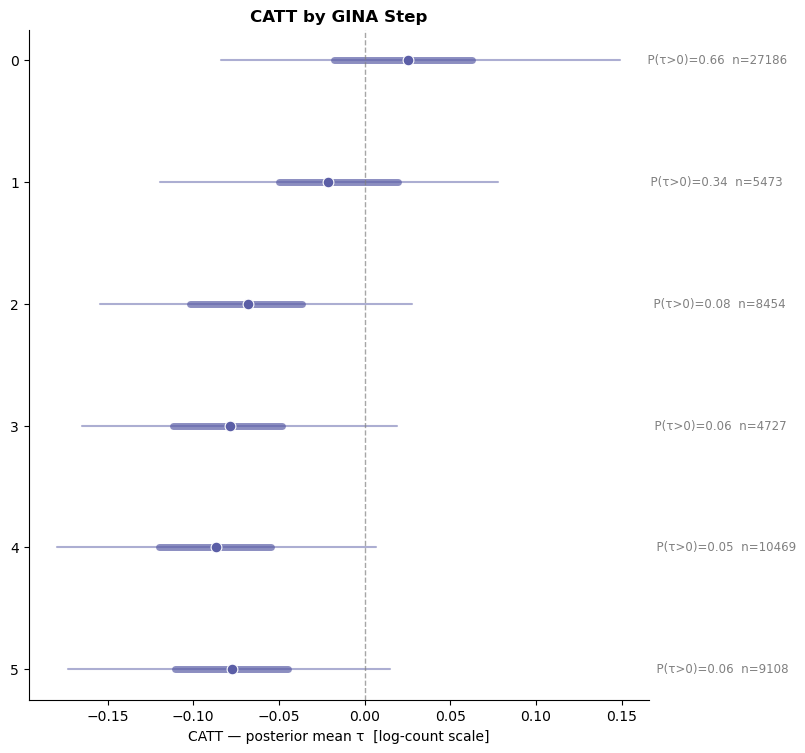

In [21]:
def catt_summary(tau_flat, idx):
    """Return (mean, lo94, hi94, P(tau>0)) for a subgroup index array."""
    draws = tau_flat[:, idx].mean(axis=1)
    hdi = az.hdi(draws, hdi_prob=0.94)
    return draws.mean(), hdi[0], hdi[1], (draws > 0).mean()

def plot_CATT_categorical(trace, covariate_array, feature_name,
                          level_labels=None, ax=None, color="#5B5EA6"):
    """
    covariate_array : 1-D array of category labels/codes for each unit
    level_labels    : dict mapping raw value to display label
    """
    tau_flat = get_tau_samples(trace)
    levels   = np.unique(covariate_array)

    if level_labels is None:
        level_labels = {v: str(v) for v in levels}

    rows = []
    for lv in levels:
        idx  = np.where(covariate_array == lv)[0]
        mean, lo94, hi94, p_pos = catt_summary(tau_flat, idx)
        # Also compute 50% HDI for inner band
        draws_lv = tau_flat[:, idx].mean(axis=1)
        lo50, hi50 = az.hdi(draws_lv, hdi_prob=0.50)
        rows.append(dict(level=level_labels[lv], n=len(idx),
                         mean=mean, lo94=lo94, hi94=hi94,
                         lo50=lo50, hi50=hi50, p_pos=p_pos))

    df = pd.DataFrame(rows)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 1.2 * len(df) + 1.5))

    y_pos = np.arange(len(df))[::-1]            # top = first level

    for i, (_, row) in enumerate(df.iterrows()):
        y = y_pos[i]
        ax.plot([row.lo94, row.hi94], [y, y], lw=1.5,
                color=color, alpha=0.5, solid_capstyle="round")
        ax.plot([row.lo50, row.hi50], [y, y], lw=5,
                color=color, alpha=0.7, solid_capstyle="round")
        ax.scatter(row["mean"], y, s=60, color=color,
                   zorder=5, edgecolors="white", linewidths=0.8)
        # P(τ > 0)
        ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] != 0 else row.hi94 + 0.01,
                y, f"  P(τ>0)={row.p_pos:.2f}  n={row.n}",
                va="center", fontsize=8.5, color="gray")

    ax.axvline(0, color="gray", lw=1, linestyle="--", alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["level"].values, fontsize=10)
    ax.set_xlabel("CATT — posterior mean τ  [log-count scale]", fontsize=10)
    ax.set_title(f"CATT by {feature_name}", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    return ax, df

plot_CATT_categorical(trace_bcf, X['gina_step'].to_numpy(), "GINA Step")

In [22]:
# Forest plot for multiple covariates
def plot_forest_multiple(trace, X, feature_names, ax=None, color="#5B5EA6"):
    """
    Parameters
    ----------
    covariate_array : 1-D array of category labels/codes for each covariate (e.g. age group, comorbidity count group, etc.)
    """
    tau_flat = get_tau_samples(trace)
    feature_idx = [X.columns.get_loc(col) for col in feature_names]
    rows = []
    for feat in feature_idx:
        covariate_array = X.iloc[:, feat].to_numpy()
        idx = np.where(covariate_array == 1)[0]
        mean, lo94, hi94, p_pos = catt_summary(tau_flat, idx)
        # Also compute 50% HDI for inner band
        draws_lv = tau_flat[:, idx].mean(axis=1)
        lo50, hi50 = az.hdi(draws_lv, hdi_prob=0.50)
        rows.append(dict(n=len(idx),
                         mean=mean, lo94=lo94, hi94=hi94,
                         lo50=lo50, hi50=hi50, p_pos=p_pos))

    df = pd.DataFrame(rows, index=feature_names)      

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 1.2 * len(df) + 1.5))

    y_pos = np.arange(len(df))[::-1]            # top = first level

    for i, (_, row) in enumerate(df.iterrows()):
        y = y_pos[i]
        # 94% HDI — thin line
        ax.plot([row.lo94, row.hi94], [y, y], lw=1.5,
                color=color, alpha=0.5, solid_capstyle="round")
        # 50% HDI — thick line
        ax.plot([row.lo50, row.hi50], [y, y], lw=5,
                color=color, alpha=0.7, solid_capstyle="round")
        # Posterior mean dot
        ax.scatter(row["mean"], y, s=60, color=color,
                   zorder=5, edgecolors="white", linewidths=0.8)
        # P(τ > 0) annotation on right
        ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] != 0 else row.hi94 + 0.01,
                y, f"  P(τ>0)={row.p_pos:.2f}  n={row.n}",
                va="center", fontsize=8.5, color="gray")

    ax.axvline(0, color="gray", lw=1, linestyle="--", alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df.index, fontsize=10)
    ax.set_xlabel("CATT — posterior mean τ  [log-count scale]", fontsize=10)
    ax.set_title(f"CATT by Multiple Covariates", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    return ax, df

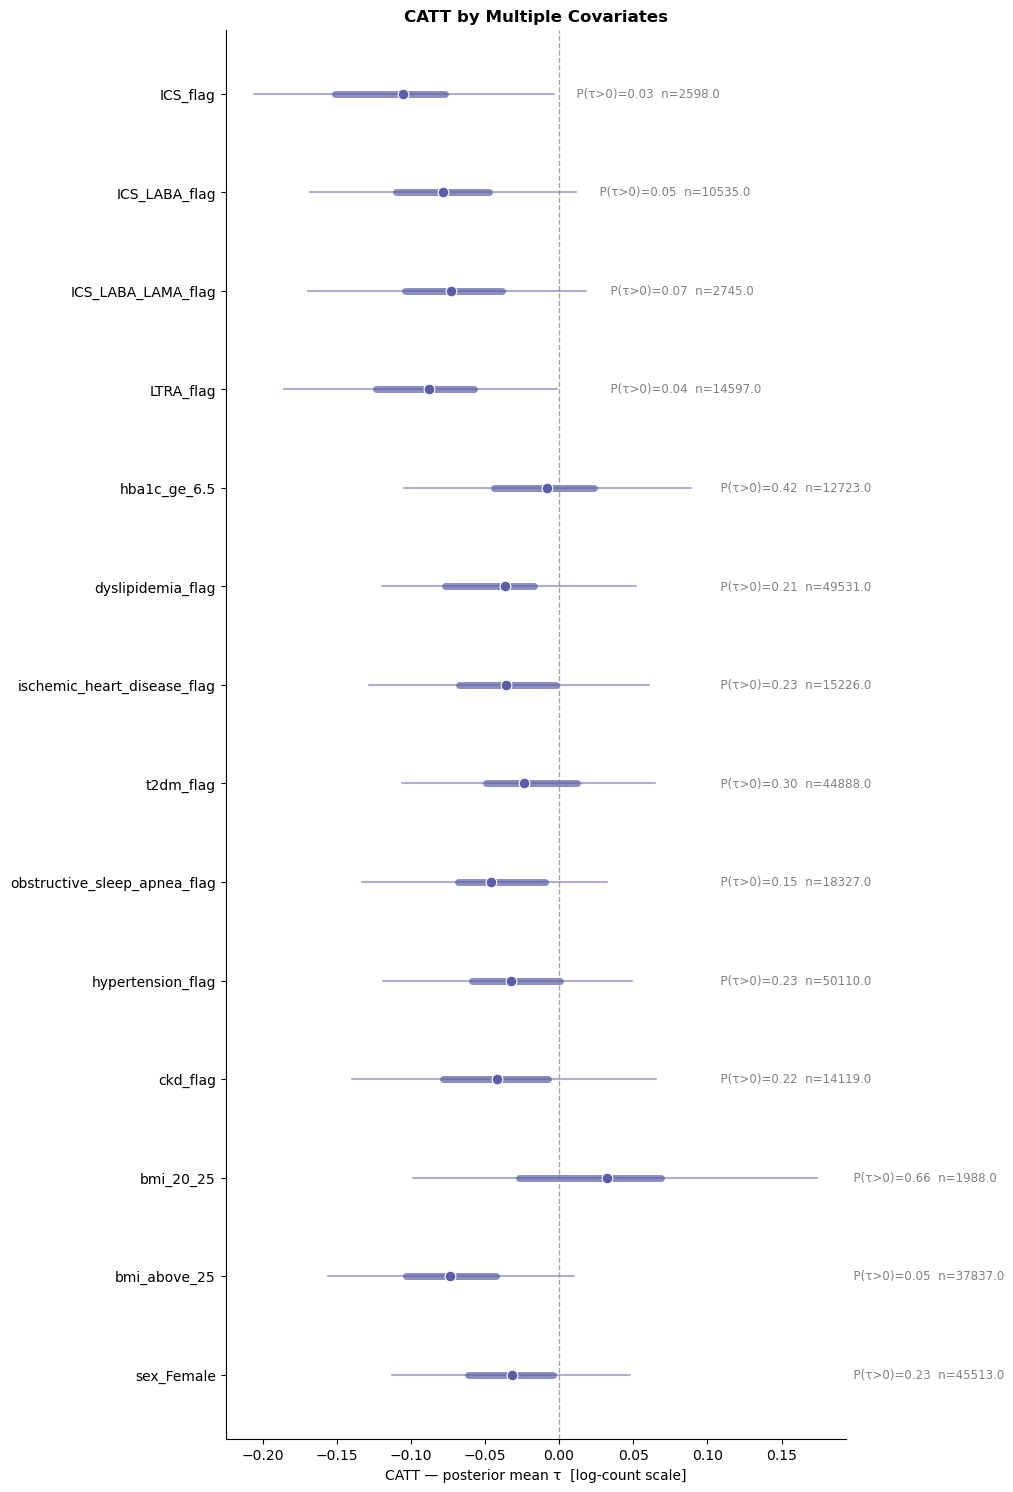

In [23]:
feature_list = [
    "ICS_flag", 
    "ICS_LABA_flag",
    "ICS_LABA_LAMA_flag",
    "LTRA_flag",
    "hba1c_ge_6.5",
    "dyslipidemia_flag",
    "ischemic_heart_disease_flag", 
    "t2dm_flag",    
    "obstructive_sleep_apnea_flag",
    "hypertension_flag",
    "ckd_flag",
    "bmi_20_25",
    "bmi_above_25",
    "sex_Female",
    ]
ax, catt_df = plot_forest_multiple(
    trace_bcf, 
    X, 
    feature_names=feature_list, 
    ax=None)

In [24]:
catt_df

,n,mean,lo94,hi94,lo50,hi50,p_pos
ICS_flag,2598,-0.105497,-0.205948,-0.003704,-0.151338,-0.077222,0.02500
ICS_LABA_flag,10535,-0.078638,-0.167979,0.011443,-0.110141,-0.047386,0.05325
ICS_LABA_LAMA_flag,2745,-0.073243,-0.169680,0.018271,-0.104197,-0.038215,0.07150
LTRA_flag,14597,-0.087596,-0.185465,-0.001098,-0.123400,-0.057297,0.03500
hba1c_ge_6.5,12723,-0.008147,-0.104814,0.089030,-0.043710,0.023278,0.41550
dyslipidemia_flag,49531,-0.036668,-0.119281,0.051552,-0.077282,-0.016907,0.20950
ischemic_heart_disease_flag,15226,-0.035681,-0.128177,0.060855,-0.067760,-0.002261,0.23200
t2dm_flag,44888,-0.023823,-0.106263,0.064932,-0.049225,0.012071,0.30150
obstructive_sleep_apnea_flag,18327,-0.045713,-0.133071,0.032446,-0.068137,-0.009501,0.14800
hypertension_flag,50110,-0.032257,-0.118693,0.049246,-0.059095,0.000262,0.22900
